# Adult Census Income Prediction
*Charlie Ardern*

Here, I'm using the UCI Machine Learning Repository [Adult Census Income Dataset](https://www.kaggle.com/datasets/uciml/adult-census-income) from Kaggle. The purpose of this notebook is just to help me brush up on some of the data science basics with pandas, sklearn, regression, classification etc. The data is from 1994 and has a set of continuous and categorical features which describe each person, and a field which determines whether their income is greater than or less than 50K. I'm trying to get a general data science background here so I'm purposely sticking to classical ML stuff and not using deep learning.

<hr>

## Loading the data

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uciml/adult-census-income")

print("Path to dataset files:", path)

/Users/charlieardern/Desktop/mini-ml-projects/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /Users/charlieardern/.cache/kagglehub/datasets/uciml/adult-census-income/versions/3


In [2]:
import pandas as pd
import numpy as np

data = pd.read_csv("/Users/charlieardern/.cache/kagglehub/datasets/uciml/adult-census-income/versions/3/adult.csv")

<hr>

## Analysing the data

In [3]:
print(data.head())

   age workclass  fnlwgt     education  education.num marital.status  \
0   90         ?   77053       HS-grad              9        Widowed   
1   82   Private  132870       HS-grad              9        Widowed   
2   66         ?  186061  Some-college             10        Widowed   
3   54   Private  140359       7th-8th              4       Divorced   
4   41   Private  264663  Some-college             10      Separated   

          occupation   relationship   race     sex  capital.gain  \
0                  ?  Not-in-family  White  Female             0   
1    Exec-managerial  Not-in-family  White  Female             0   
2                  ?      Unmarried  Black  Female             0   
3  Machine-op-inspct      Unmarried  White  Female             0   
4     Prof-specialty      Own-child  White  Female             0   

   capital.loss  hours.per.week native.country income  
0          4356              40  United-States  <=50K  
1          4356              18  United-States

My objective is to predict income based on demographic, education, and employment characteristics, so I'm going to remove the columns on capital losses and gains.

In [4]:
data.drop(columns=['capital.gain', 'capital.loss'], inplace=True)

In [5]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  hours.per.week  32561 non-null  int64 
 11  native.country  32561 non-null  object
 12  income          32561 non-null  object
dtypes: int64(4), object(9)
memory usage: 3.2+ MB
None


In [6]:
print(data.describe())

                age        fnlwgt  education.num  hours.per.week
count  32561.000000  3.256100e+04   32561.000000    32561.000000
mean      38.581647  1.897784e+05      10.080679       40.437456
std       13.640433  1.055500e+05       2.572720       12.347429
min       17.000000  1.228500e+04       1.000000        1.000000
25%       28.000000  1.178270e+05       9.000000       40.000000
50%       37.000000  1.783560e+05      10.000000       40.000000
75%       48.000000  2.370510e+05      12.000000       45.000000
max       90.000000  1.484705e+06      16.000000       99.000000


<Figure size 1000x1000 with 0 Axes>

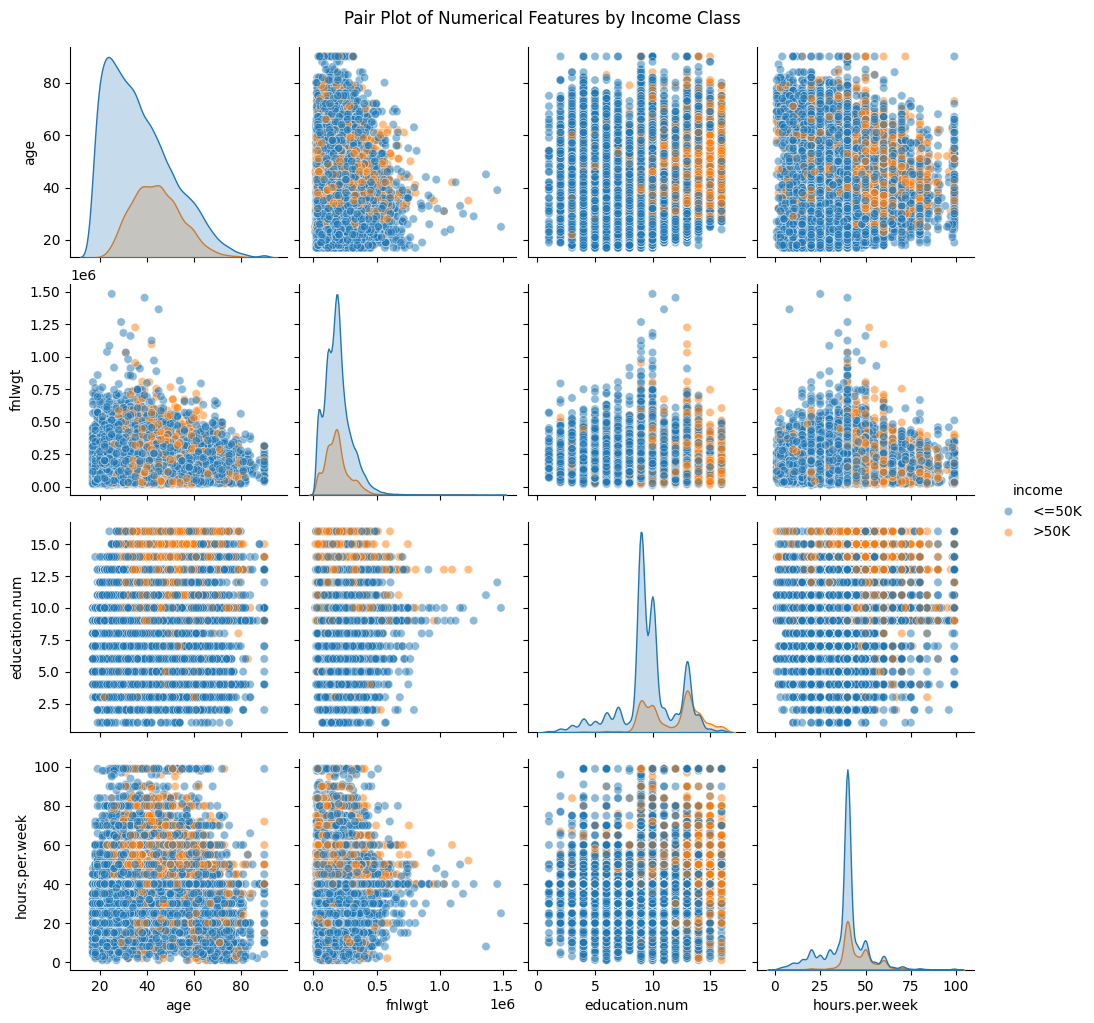

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

numerical_cols = [
    'age',
    'fnlwgt',
    'education.num',
    'hours.per.week'
]
numerical_data = data[numerical_cols]
data_plot = data[numerical_cols + ['income']]

plt.figure(figsize=(10,10))
sns.pairplot(
    data=data_plot,
    hue = 'income',
    diag_kind = 'kde',
    plot_kws={'alpha': 0.5}
)
plt.suptitle('Pair Plot of Numerical Features by Income Class', y=1.02)
plt.show()

## Choosing a model
As there are a mixture of categorical and numerical features here, it's seems like a decision tree might be a good choice. I'll start with a random forest, then compare this with XGBoost.

## Preparing the features

This data contains a lot of rows with a '?' in the workclass, occupation and country columns, representing a missing value. I will simply treat '?' as its own category, as imputing with the mode could introduce the risk of the model learning very wrong information. There could be some corelation between which entries have missing values (e.g. state of residence) which could correlate with other variables, and this information could be preserved by treating '?' as its own feature. I will ideally come back to this later and test mode imputation out to compare the accuracy.

In [8]:
# Temporarily swapping the '?' for nans so we can count them!
data_with_nans = data.replace('?', np.nan)

missing_values_count = data_with_nans.isnull().sum()
print(missing_values_count)

age                  0
workclass         1836
fnlwgt               0
education            0
education.num        0
marital.status       0
occupation        1843
relationship         0
race                 0
sex                  0
hours.per.week       0
native.country     583
income               0
dtype: int64


### Encoding the categorical features
As shown below, each of these have quite a few different categories. I've found native country to be heavily dominated by the US, with many different countries on the list. This will create a lot of features if I use one-hot encoding. I'll tackle this by turning it into one category call 'united.states' where 1 is from the United States and 0 is from other countries. I'll then use one-hot encoding on the rest of the categorical features.

In [9]:
print(data['native.country'].nunique())

42


In [10]:
print(data['native.country'].value_counts())

native.country
United-States                 29170
Mexico                          643
?                               583
Philippines                     198
Germany                         137
Canada                          121
Puerto-Rico                     114
El-Salvador                     106
India                           100
Cuba                             95
England                          90
Jamaica                          81
South                            80
China                            75
Italy                            73
Dominican-Republic               70
Vietnam                          67
Guatemala                        64
Japan                            62
Poland                           60
Columbia                         59
Taiwan                           51
Haiti                            44
Iran                             43
Portugal                         37
Nicaragua                        34
Peru                             31
Greece       

Clearly, there is a reasonable split between different occupations, and a less even split between workclass. Native country is the most uneven, and 

In [11]:
data['united.states'] = (data['native.country'] == 'United-States').astype(int)

In [12]:
#data.drop(["education","native.country"], axis=1,inplace=True)

In [13]:
print(data.head())

   age workclass  fnlwgt     education  education.num marital.status  \
0   90         ?   77053       HS-grad              9        Widowed   
1   82   Private  132870       HS-grad              9        Widowed   
2   66         ?  186061  Some-college             10        Widowed   
3   54   Private  140359       7th-8th              4       Divorced   
4   41   Private  264663  Some-college             10      Separated   

          occupation   relationship   race     sex  hours.per.week  \
0                  ?  Not-in-family  White  Female              40   
1    Exec-managerial  Not-in-family  White  Female              18   
2                  ?      Unmarried  Black  Female              40   
3  Machine-op-inspct      Unmarried  White  Female              40   
4     Prof-specialty      Own-child  White  Female              40   

  native.country income  united.states  
0  United-States  <=50K              1  
1  United-States  <=50K              1  
2  United-States  <=50K

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

X = data.drop("income", axis=1)
y = data["income"]
fnlwgt = data["fnlwgt"].values

categorical_features = ["workclass", "marital.status", "occupation", "relationship", "race", "sex", "native.country"]
numerical_features = ["age", "education.num", "hours.per.week"]

preprocessor = ColumnTransformer(transformers=[("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
                                               ("num", "passthrough", numerical_features)], remainder="drop")

## Random Forest

In [15]:
from sklearn.ensemble import RandomForestClassifier

pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', RandomForestClassifier(n_estimators=500, random_state=42, max_depth=None, min_samples_leaf=2, class_weight="balanced"))])

X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(X, y, fnlwgt, test_size=0.2, random_state=42)
pipeline.fit(X_train, y_train, classifier__sample_weight=w_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


[[4057  919]
 [ 313 1224]]


Text(0.5, 1.0, 'Test data confusion matrix')

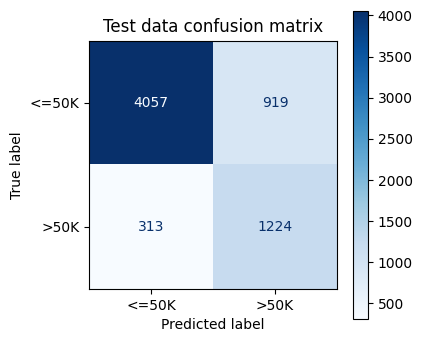

In [16]:
y_pred = pipeline.predict(X_test)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
cm = confusion_matrix(y_test, y_pred)
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["<=50K", ">50K"])
fig, ax = plt.subplots(figsize=(4,4))
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title("Test data confusion matrix")

[[16583  3161]
 [  639  5665]]


Text(0.5, 1.0, 'Train data confusion matrix')

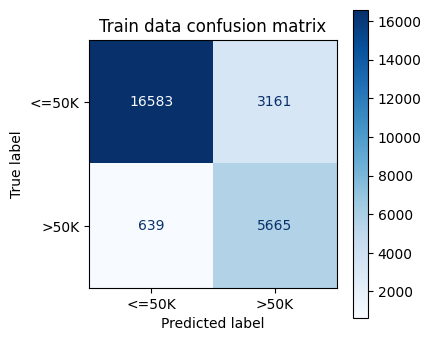

In [17]:
y_pred = pipeline.predict(X_train)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
cm = confusion_matrix(y_train, y_pred)
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["<=50K", ">50K"])
fig, ax = plt.subplots(figsize=(4,4))
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title("Train data confusion matrix")

## XGBoost

In [18]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

xgb_pipeline = Pipeline(steps=[("preprocessor", preprocessor),("classifier", XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=None, scale_pos_weight=1.5, random_state=42, n_jobs=-1, eval_metric="logloss"))])

# Converting ">50K" and "<=50K" to 1 and 0 for xgboost
le = LabelEncoder()

y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

xgb_pipeline.fit(X_train, y_train_encoded, classifier__sample_weight=w_train)

y_pred_xgb = xgb_pipeline.predict(X_test)

[[4331  645]
 [ 438 1099]]


Text(0.5, 1.0, 'Test Confusion Matrix')

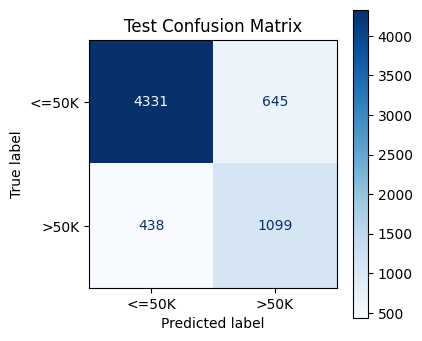

In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
cm = confusion_matrix(y_test_encoded, y_pred_xgb)
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["<=50K", ">50K"])
fig, ax = plt.subplots(figsize=(4,4))
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title("Test Confusion Matrix")

[[17476  2268]
 [ 1321  4983]]


Text(0.5, 1.0, 'Train Confusion Matrix')

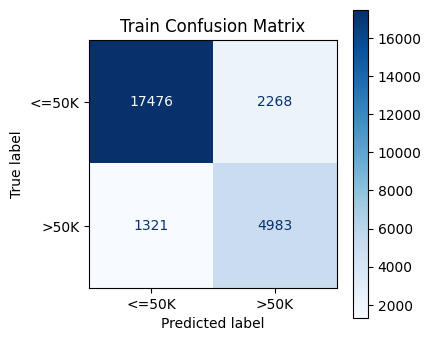

In [20]:
y_pred_train_xgb = xgb_pipeline.predict(X_train)
cm = confusion_matrix(y_train_encoded, y_pred_train_xgb)
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["<=50K", ">50K"])
fig, ax = plt.subplots(figsize=(4,4))
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title("Train Confusion Matrix")

These predictions look pretty garbage to me